In [2]:
import sys
sys.path.append("/home/mariacst/exoplanets/exoplanets/cluster/")

import derivatives
import imp
imp.reload(derivatives)
import numpy as np

from astropy.constants import G, sigma_sb, R_jup, c, M_sun
import astropy.units as u

import matplotlib.pyplot as plt

# Second derivative temperature with respect to mass

**Second derivative TDM wrt mass**

In [6]:
imp.reload(derivatives)
from derivatives import dderivativeTDM_wrt_M, dderivativeT_wrt_M
from scipy.misc import derivative

In [7]:
path = "/home/mariacst/exoplanets/running/data/"

masses, a, b = np.genfromtxt(path + "derv_ana_wrt_A.dat", unpack=True)           
ages, c = np.genfromtxt(path + "derv_ana_wrt_M.dat", unpack=True)             

from scipy.interpolate import interp1d
from scipy.interpolate import griddata

a_interp = interp1d(masses, a)                                                   
b_interp = interp1d(masses, b)                                                    
c_interp = interp1d(ages, c)
                                  
data = np.genfromtxt(path + "./ATMO_CEQ_vega_MIRI.txt", unpack=True)               
points = np.transpose(data[0:2, :])                                                
values = data[2] 

In [8]:
r=0.1; f=1.; params=[1., 20., 0.42]; v=100.; 
M=0.035; A=5.

masses = np.linspace(0.02, 0.045, 10)

In [19]:
_sigma_sb               = sigma_sb.value                                                      
_G                      = G.value 
conversion_into_K_vs_kg = 1.60217e-7
conv_Msun_to_kg         = 1.98841e+30
conversion_into_w       = 0.16021766

from utils import gNFW_rho, T_DM

def derivativeTDM_wrt_M(M, r, f, params, v, R=R_jup.value, Rsun=8.178, epsilon=1):                                                
    """                                                                            
    Return (analytical) derivative of DM temperature wrt mass @                    
    (f, gamma, rs, rho0, r, M, R) [K/Msun]                                         
                                                                                   
    Input                                                                          
    -----                                                                          
        r      : Galactocentric distance [kpc]                                     
        params : DM parameters [f, gamma, rs]                                      
        M      : exoplanet mass [Msun]                                             
    """                                                                            
    # escape velocity                                                              
    vesc   = np.sqrt(2*_G*M*conv_Msun_to_kg/R)*1e-3 # km/s                         
    if v:                                                                          
        _vD = v                                                                    
        #print(_vD, "here i am")                                                   
    else:                                                                          
        _vD    = np.sqrt(3/2.)*vc(Rsun, r, params) # km/s                          
                                                                                   
    _vDM   =  np.sqrt(8./(3*np.pi))*_vD # km/s                                     
    _rhoDM = gNFW_rho(Rsun, r, params) # GeV/cm3                                   
                                                                                   
    # DM temperature^-3 [1/K^3]                                                    
    T_DM3 = np.power((f*_rhoDM*_vDM*(1+3./2.*np.power(vesc/_vD, 2))*               
                     conversion_into_w)/(4*_sigma_sb*epsilon), -3./4.)             
    # return                                                                       
    return (T_DM3*3./16.*np.sqrt(8./3./np.pi)*f/_sigma_sb/                         
            epsilon*_rhoDM*_G/_vD/R*                                               
            conversion_into_K_vs_kg*conv_Msun_to_kg                                
           )                                                                       

dd_num  = []
dd_ana  = []
TDM_ana = []
for M in masses:

    TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    TDM_ana.append(TDM)

    dd_num.append(derivative(derivativeTDM_wrt_M, M, args=(r, f, params, v), dx=1e-5, order=3))
    
    dervTDM_M = derivativeTDM_wrt_M(M, r, f, params, v)
    print(dervTDM_M)
    
    dd_ana.append(dderivativeTDM_wrt_M(TDM, dervTDM_M))

5511.854151040934
5037.624590637332
4648.820384135921
4323.51307626488
4046.7958093807993
3808.159127857657
3599.9675231140814
3416.531510069276
3253.519325323984
3107.571049409754


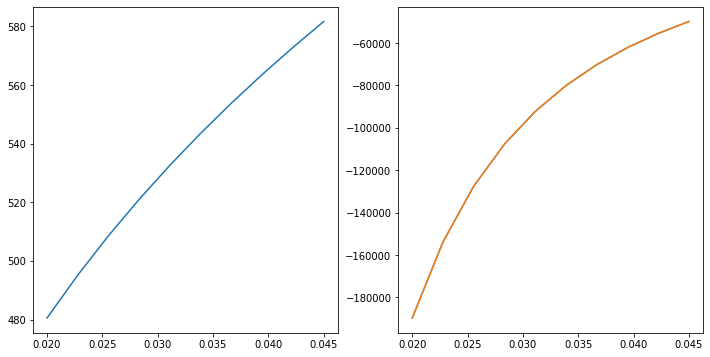

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(masses, TDM_ana)
ax[1].plot(masses, dd_num, label="num")
ax[1].plot(masses, dd_ana, label="ana")

In [ ]:
imp.reload(derivatives)
from derivatives import derivativeTDM_wrt_M, dderivativeT_wrt_M
from utils import T_DM

def derivativeT_wrt_M(M, r, A, f, params, v, c, Tint, TDM, Ttot):
    return (Tint/Ttot)**3*c(A) +  (TDM/Ttot)**3*derivativeTDM_wrt_M(r, f, params, M, v)

dd_num = []
dd_ana = []

Ttot = []; Tint = []; TDM = []
derv = []

for M in masses:
    xi   = np.transpose(np.asarray([A, M]))
    _Tint = griddata(points, values, xi)[0]
    Tint.append(_Tint)
    _TDM  = T_DM(r, M=M*M_sun.value, f=f, params=params, v=v)
    TDM.append(_TDM)
    _Ttot = np.power(_Tint**4+_TDM**4, 0.25)
    Ttot.append(_Ttot)
    
    derv.append(derivativeT_wrt_M(M, r, A, f, params, v, c_interp, _Tint, _TDM, _Ttot))
    
    dd_num.append(derivative(derivativeT_wrt_M, M, args=(r, A, f, params, v, c_interp, _Tint, _TDM, _Ttot), 
                             dx=1e-5, order=15))
    
    dd_ana.append(dderivativeT_wrt_M(r, M, A, _Tint, _TDM, _Ttot, c_interp, f, params, v))

ERROR:root:
UnicodeDecodeError while processing traceback.

ERROR:root:
UnicodeDecodeError while processing traceback.

ERROR:root:
UnicodeDecodeError while processing traceback.



456.451376 480.5400069512362 557.689991982679 5511.854151040934


--- Logging error ---
--- Logging error ---
--- Logging error ---
--- Logging error ---
--- Logging error ---
Error in sys.excepthook:
Traceback (most recent call last):
  File "/usr/lib64/python3.6/linecache.py", line 47, in getlines
    return updatecache(filename, module_globals)
  File "/usr/lib64/python3.6/linecache.py", line 137, in updatecache
    lines = fp.readlines()
  File "/usr/lib64/python3.6/codecs.py", line 321, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc3 in position 5666: invalid continuation byte

Original exception was:
Traceback (most recent call last):
  File "/home/mariacst/exoplanets/.venv/lib64/python3.6/site-packages/IPython/core/interactiveshell.py", line 3343, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-9-dbf0ad05eacd>", line 28, in <module>
  File "/home/mariacst/exoplanets/exoplanets/cluster/derivatives.py", line 167, in 

    (result, consumed) = self._buffer_decode(data, self.errors, final)
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc3 in position 5666: invalid continuation byte

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib64/python3.6/logging/__init__.py", line 994, in emit
    msg = self.format(record)
  File "/usr/lib64/python3.6/logging/__init__.py", line 840, in format
    return fmt.format(record)
  File "/usr/lib64/python3.6/logging/__init__.py", line 585, in format
    record.exc_text = self.formatException(record.exc_info)
  File "/usr/lib64/python3.6/logging/__init__.py", line 535, in formatException
    traceback.print_exception(ei[0], ei[1], tb, None, sio)
  File "/usr/lib64/python3.6/traceback.py", line 104, in print_exception
    type(value), value, tb, limit=limit).format(chain=chain):
  File "/usr/lib64/python3.6/traceback.py", line 522, in __init__
    self._load_lines()
  File "/usr/lib64/python3.6/

Text(0.5, 0, 'M [Msun]')

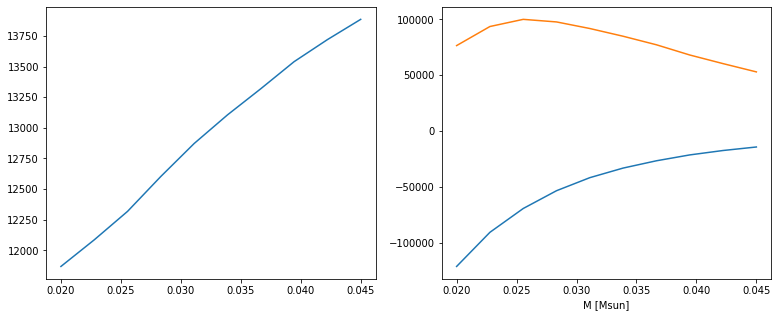

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].plot(masses, derv)
#ax[0].plot(masses, Ttot); ax[0].set_ylabel("M [Msun]"); ax[0].set_ylabel("Ttot [K]")
#ax[0].plot(masses, Tint, label="int"); ax[0].plot(masses, TDM, label="DM")
#ax[0].legend()

ax[1].plot(masses, dd_num, label="num")
ax[1].plot(masses, dd_ana, label="ana")
ax[1].set_xlabel("M [Msun]")

# Second derivative temperature with respect to age

In [10]:
import derivatives
import imp
imp.reload(derivatives)
import numpy as np

from derivatives import dderivativeT_wrt_A

In [14]:
dderivativeT_wrt_A(masses[6], ages[6], 1., 1., a_interp, b_interp)

90.00315681709114

# Second derivative temperature with respect to Galactocentric distance

In [2]:
from derivatives import dderivativeT_wrt_r

In [3]:
dderivativeT_wrt_r(0.2, 1., [0.8, 20., 0.42], 0.017, 100., 1., 1.)

351.1772556289588